# Experiment No. 10 — Genetic Algorithm for Function Minimization


---

## 1. Problem + Algorithm

### Title
Genetic Algorithm for Function Minimization.

### Aim
Implement a Genetic Algorithm to minimize a given objective function using
binary-coded chromosomes and a real-valued decoding formula.

### Problem Statement
Solve a **minimization** problem where

$$f(x) = -x^{2} + 2x, \qquad 0 \le x \le 2$$

with a population of four chromosomes `11010`, `00111`, `10110`, `00101`, and
random numbers $0.4,\ 0.15,\ 0.7,\ 0.9$. The crossover point is the **1st bit**
of the 5-bit chromosome.

Use the decoding (encoding) formula

$$x = x_{min} + \frac{x_{max} - x_{min}}{2^{L} - 1} \times (\text{decimal value})$$

with $x_{min} = 0$, $x_{max} = 2$, $L = 5$ bits (so $2^5 - 1 = 31$).

*Check:* chromosome `10110` → decimal 22 →
$x = 0 + \frac{2-0}{31} \times 22 = \frac{44}{31} = 1.419$.

### Given Parameter Settings

| Parameter | Value |
|---|---|
| Objective function | $f(x) = -x^2 + 2x$ |
| Goal | **minimize** |
| Domain | $0 \le x \le 2$ |
| Chromosome length $L$ | 5 bits |
| Population size $N$ | 4 |
| Initial population | `11010`, `00111`, `10110`, `00101` |
| Random numbers | $r_1 = 0.40,\ r_2 = 0.15,\ r_3 = 0.70,\ r_4 = 0.90$ |
| Crossover site | 1 (after the 1st bit) |
| Mutation probability | 0 (not specified in the problem) |

### Assumptions made explicit
Two details are not fully specified in the problem, so they are stated here
rather than silently guessed:

1. **The four random numbers** $r_1, r_2, r_3, r_4$ are used with the standard
   *roulette-wheel + cumulative-probability* method: for each $r$, select the
   first chromosome whose cumulative probability is $\ge r$. Four random numbers
   supplied alongside four selection probabilities admits no other natural
   reading.
2. **Minimization requires a fitness transform.** Roulette-wheel selection
   always favours *higher* fitness, so the objective cannot be used directly
   when the goal is to minimize it. The standard transform is applied:
   $$\text{fitness}(x) = \frac{1}{1 + f(x)}$$
   This is valid here because $f(x) = x(2-x) \ge 0$ on $[0, 2]$, so the
   denominator is always positive and finite. The transform is *decreasing* in
   $f(x)$: smaller $f(x)$ → larger fitness → higher chance of selection, which
   is exactly what minimization demands.

### Algorithm
1. **Initialize population** of $N$ binary chromosomes of length $L$.
2. **Decode** each chromosome to a real $x$ using the formula above.
3. **Evaluate the objective** $f(x) = -x^2 + 2x$ for every individual.
4. **Apply the minimization fitness transform** $\text{fitness} = 1/(1 + f(x))$.
5. **Compute selection probabilities** and their **cumulative sums**.
6. **Select** the mating pool by roulette wheel, using the supplied random
   numbers.
7. **Apply crossover** at the given site (1st bit).
8. **Apply mutation** (bit-flip) with a small probability per bit.
9. **Replace** the old population with the new one.
10. **Repeat** steps 2–9 until convergence or the generation limit.
11. **Return** the chromosome with the **lowest** $f(x)$ seen.

### Note on where the true minimum lies
$f(x) = -x^2 + 2x = x(2-x)$ is a **downward-opening** parabola. Setting
$f'(x) = -2x + 2 = 0$ gives $x = 1$, but $f''(x) = -2 < 0$, so $x = 1$ is a
**maximum**, not a minimum. On the closed interval $[0, 2]$ the minimum
therefore occurs at a **boundary** point: $f(0) = f(2) = 0$. The GA must drive
chromosomes towards `00000` or `11111` — the two extremes of the encoding.

---

## 2. Program

### Function definitions and decoding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

X_MIN, X_MAX, L = 0, 2, 5


def f(x):
    # Objective function to be MINIMIZED: f(x) = -x^2 + 2x
    return -x**2 + 2*x


def decode(chromosome):
    # x = x_min + (x_max - x_min)/(2^L - 1) * decimal_value
    decimal_value = int(chromosome, 2)
    return X_MIN + (X_MAX - X_MIN) / (2**L - 1) * decimal_value


def fitness_of(x):
    # Minimization fitness transform: smaller f(x) -> larger fitness
    return 1.0 / (1.0 + f(x))


# sanity check on the decoding formula given in the problem
print(f"Check: decode('10110') = {decode('10110'):.3f}   (expected 1.419)")
print(f"       decode('00000') = {decode('00000'):.3f}, "
      f"decode('11111') = {decode('11111'):.3f}")

Check: decode('10110') = 1.419   (expected 1.419)
       decode('00000') = 0.000, decode('11111') = 2.000


### Genetic operators

In [2]:
def crossover(parent_a, parent_b, site):
    # Single-point crossover: keep the first `site` bits, swap the rest
    child1 = parent_a[:site] + parent_b[site:]
    child2 = parent_b[:site] + parent_a[site:]
    return child1, child2


def mutate(chromosome, pm, rng):
    # Bit-flip mutation applied independently to each bit with probability pm
    bits = list(chromosome)
    for i in range(len(bits)):
        if rng.random() < pm:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)


def select_index(r, cumulative_prob):
    # Roulette wheel: first chromosome whose cumulative probability >= r
    for i, cp in enumerate(cumulative_prob):
        if r <= cp:
            return i
    return len(cumulative_prob) - 1

### Core algorithm — the iterated loop

In [3]:
def run_ga(pop_size=4, site=1, pm=0.0, generations=5, seed=1,
            initial_population=None, supplied_randoms=(0.40, 0.15, 0.70, 0.90)):
    # Iterated GA minimizing f(x) = -x^2 + 2x on [0, 2].
    # The supplied random numbers are used for the first generation's
    # selection; later generations continue with a seeded RNG.
    rng = np.random.default_rng(seed)

    if initial_population is not None:
        population = list(initial_population)
    else:
        population = [format(int(rng.integers(0, 2**L)), f'0{L}b')
                      for _ in range(pop_size)]
    pop_size = len(population)

    best_chromo, best_x = None, None
    best_f = np.inf
    log = []

    for gen in range(1, generations + 1):
        x_vals = [decode(ch) for ch in population]
        f_vals = [f(x) for x in x_vals]
        fits = [fitness_of(x) for x in x_vals]

        gen_best = int(np.argmin(f_vals))      # minimization -> smallest f wins
        if f_vals[gen_best] < best_f:
            best_f = f_vals[gen_best]
            best_chromo, best_x = population[gen_best], x_vals[gen_best]

        log.append({'Generation': gen,
                    'Best Chromosome': population[gen_best],
                    'Best x': round(x_vals[gen_best], 4),
                    'Min f(x)': round(f_vals[gen_best], 4),
                    'Avg f(x)': round(float(np.mean(f_vals)), 4),
                    'Max f(x)': round(float(np.max(f_vals)), 4),
                    'Best-so-far f(x)': round(best_f, 4),
                    'Distinct chromosomes': len(set(population))})

        # ---- selection ----
        total_fit = sum(fits)
        cum = np.cumsum([fit / total_fit for fit in fits])
        if gen == 1 and supplied_randoms is not None:
            draws = list(supplied_randoms)[:pop_size]
            while len(draws) < pop_size:
                draws.append(float(rng.random()))
        else:
            draws = [float(rng.random()) for _ in range(pop_size)]
        mating_pool = [population[select_index(r, cum)] for r in draws]

        # ---- crossover at the given site ----
        children = []
        for i in range(0, pop_size - 1, 2):
            ch1, ch2 = crossover(mating_pool[i], mating_pool[i + 1], site)
            children.extend([ch1, ch2])
        if len(children) < pop_size:
            children.append(mating_pool[-1])

        # ---- mutation ----
        children = [mutate(ch, pm, rng) for ch in children]

        population = children

    return best_chromo, best_x, best_f, pd.DataFrame(log)

### Key parameter settings (original configuration)

In [4]:
INITIAL_POPULATION = ['11010', '00111', '10110', '00101']
RANDOM_NUMBERS = [0.40, 0.15, 0.70, 0.90]
SITE = 1

PARAMS = dict(pop_size=4, site=SITE, pm=0.0, generations=5, seed=1,
              initial_population=INITIAL_POPULATION,
              supplied_randoms=tuple(RANDOM_NUMBERS))

print("Initial population :", INITIAL_POPULATION)
print("Random numbers     :", RANDOM_NUMBERS)
print("Crossover site     :", SITE)
for k, v in PARAMS.items():
    if k not in ('initial_population', 'supplied_randoms'):
        print(f"{k:12s} = {v}")

Initial population : ['11010', '00111', '10110', '00101']
Random numbers     : [0.4, 0.15, 0.7, 0.9]
Crossover site     : 1
pop_size     = 4
site         = 1
pm           = 0.0
generations  = 5
seed         = 1


---

## 3. Output + Analysis

### 3.1 Step 1 — Initial Population, Decoded $x$, and $f(x)$

In [5]:
population = list(INITIAL_POPULATION)
x_values = [decode(ch) for ch in population]
f_values = [f(x) for x in x_values]

gen1 = pd.DataFrame({
    'String No.': range(1, len(population) + 1),
    'Chromosome': population,
    'Decimal value': [int(ch, 2) for ch in population],
    'x (decoded)': np.round(x_values, 4),
    'f(x) = -x^2+2x': np.round(f_values, 4),
})
gen1

,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x
0,1,11010,26,1.6774,0.5411
1,2,00111,7,0.4516,0.6993
2,3,10110,22,1.4194,0.8241
3,4,00101,5,0.3226,0.5411


### 3.2 Step 2 — Minimization Fitness Transform

$$\text{fitness}(x) = \frac{1}{1 + f(x)}$$

Smaller $f(x)$ (better, since we minimize) $\Rightarrow$ larger fitness
$\Rightarrow$ more likely to be selected.

In [6]:
fitness = [fitness_of(x) for x in x_values]
total_fitness = sum(fitness)
prob = [fit / total_fitness for fit in fitness]
cumulative_prob = np.cumsum(prob)

gen1['Fitness = 1/(1+f(x))'] = np.round(fitness, 4)
gen1['Probability'] = np.round(prob, 4)
gen1['Cumulative Prob.'] = np.round(cumulative_prob, 4)

print(f"Sum of fitness      = {total_fitness:.4f}")
print(f"Sum of probabilities = {sum(prob):.4f}")
gen1

Sum of fitness      = 2.4345
Sum of probabilities = 1.0000


,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x,Fitness = 1/(1+f(x)),Probability,Cumulative Prob.
0,1,11010,26,1.6774,0.5411,0.6489,0.2665,0.2665
1,2,00111,7,0.4516,0.6993,0.5885,0.2417,0.5083
2,3,10110,22,1.4194,0.8241,0.5482,0.2252,0.7335
3,4,00101,5,0.3226,0.5411,0.6489,0.2665,1.0000


### 3.3 Step 3 — Selection using the given random numbers

Random numbers: $r_1 = 0.40,\ r_2 = 0.15,\ r_3 = 0.70,\ r_4 = 0.90$.

Rule: for each $r$, select the **first** chromosome whose cumulative
probability is $\ge r$.

In [7]:
selected_indices = [select_index(r, cumulative_prob) for r in RANDOM_NUMBERS]
mating_pool = [population[i] for i in selected_indices]

selection_table = pd.DataFrame({
    'Random no. r': RANDOM_NUMBERS,
    'Falls in cumulative band': [
        f"{0 if i == 0 else cumulative_prob[i-1]:.4f} - {cumulative_prob[i]:.4f}"
        for i in selected_indices],
    'Selected String No.': [i + 1 for i in selected_indices],
    'Selected Chromosome': mating_pool,
    'x': [round(decode(ch), 4) for ch in mating_pool],
    'f(x)': [round(f(decode(ch)), 4) for ch in mating_pool],
})
selection_table

,Random no. r,Falls in cumulative band,Selected String No.,Selected Chromosome,x,f(x)
0,0.40,0.2665 - 0.5083,2,00111,0.4516,0.6993
1,0.15,0.0000 - 0.2665,1,11010,1.6774,0.5411
2,0.70,0.5083 - 0.7335,3,10110,1.4194,0.8241
3,0.90,0.7335 - 1.0000,4,00101,0.3226,0.5411


### 3.4 Step 4 — Mating Pool

In [8]:
print("Mating Pool:")
for i, ch in enumerate(mating_pool, 1):
    print(f"  Mate {i}: {ch}   (x = {decode(ch):.4f}, f(x) = {f(decode(ch)):.4f})")

counts = pd.Series(mating_pool).value_counts()
print("\nCopies of each chromosome in the mating pool:")
print(counts.to_string())

Mating Pool:
  Mate 1: 00111   (x = 0.4516, f(x) = 0.6993)
  Mate 2: 11010   (x = 1.6774, f(x) = 0.5411)
  Mate 3: 10110   (x = 1.4194, f(x) = 0.8241)
  Mate 4: 00101   (x = 0.3226, f(x) = 0.5411)

Copies of each chromosome in the mating pool:
00111    1
11010    1
10110    1
00101    1


### 3.5 Step 5 — Crossover (single-point, site = 1)

The crossover point is the **1st bit**: the first bit of each parent is kept and
everything from bit 2 onward is swapped between the two parents in the pair.
Pairing is sequential: (mate 1, mate 2) and (mate 3, mate 4).

In [9]:
pair1 = (mating_pool[0], mating_pool[1])
pair2 = (mating_pool[2], mating_pool[3])

child1, child2 = crossover(pair1[0], pair1[1], SITE)
child3, child4 = crossover(pair2[0], pair2[1], SITE)

cross_table = pd.DataFrame([
    {'Pair': 1, 'Parent A': pair1[0], 'Parent B': pair1[1], 'Site': SITE,
     'Child 1': child1, 'Child 2': child2},
    {'Pair': 2, 'Parent A': pair2[0], 'Parent B': pair2[1], 'Site': SITE,
     'Child 1': child3, 'Child 2': child4},
])
print(cross_table.to_string(index=False))

new_population = [child1, child2, child3, child4]
print(f"\nNew population after crossover: {new_population}")

 Pair Parent A Parent B  Site Child 1 Child 2
    1    00111    11010     1   01010   10111
    2    10110    00101     1   10101   00110

New population after crossover: ['01010', '10111', '10101', '00110']


### 3.6 Step 6 — New Population: decode and evaluate (Generation 2)

In [10]:
x_values_2 = [decode(ch) for ch in new_population]
f_values_2 = [f(x) for x in x_values_2]

gen2 = pd.DataFrame({
    'String No.': range(1, len(new_population) + 1),
    'Chromosome': new_population,
    'Decimal value': [int(ch, 2) for ch in new_population],
    'x (decoded)': np.round(x_values_2, 4),
    'f(x) = -x^2+2x': np.round(f_values_2, 4),
})
gen2

,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x
0,1,01010,10,0.6452,0.8741
1,2,10111,23,1.4839,0.7659
2,3,10101,21,1.3548,0.8741
3,4,00110,6,0.3871,0.6243


### 3.7 Step 7 — Best Solution across both generations

In [11]:
combined = pd.DataFrame({
    'Generation': [1]*4 + [2]*4,
    'Chromosome': population + new_population,
    'x': np.round(x_values + x_values_2, 4),
    'f(x)': np.round(f_values + f_values_2, 4),
})
best_idx = int(np.argmin(combined['f(x)']))   # minimization -> smallest wins
print(combined.to_string(index=False))

print(f"\nBest solution over both generations:")
print(f"  chromosome = {combined.loc[best_idx, 'Chromosome']}")
print(f"  x          = {combined.loc[best_idx, 'x']}")
print(f"  f(x)       = {combined.loc[best_idx, 'f(x)']}")

print(f"\nGeneration 1: min f(x) = {min(f_values):.4f}, "
      f"avg f(x) = {np.mean(f_values):.4f}")
print(f"Generation 2: min f(x) = {min(f_values_2):.4f}, "
      f"avg f(x) = {np.mean(f_values_2):.4f}")

 Generation Chromosome      x   f(x)
          1      11010 1.6774 0.5411
          1      00111 0.4516 0.6993
          1      10110 1.4194 0.8241
          1      00101 0.3226 0.5411
          2      01010 0.6452 0.8741
          2      10111 1.4839 0.7659
          2      10101 1.3548 0.8741
          2      00110 0.3871 0.6243

Best solution over both generations:
  chromosome = 11010
  x          = 1.6774
  f(x)       = 0.5411

Generation 1: min f(x) = 0.5411, avg f(x) = 0.6514
Generation 2: min f(x) = 0.6243, avg f(x) = 0.7846


### 3.8 Step 8 — Analytical Verification

In [12]:
import sympy as sp

xs = sp.symbols('x')
f_sym = -xs**2 + 2*xs
f1, f2 = sp.diff(f_sym, xs), sp.diff(f_sym, xs, 2)
crit = sp.solve(sp.Eq(f1, 0), xs)[0]

print(f"f(x)   = {f_sym}")
print(f"f'(x)  = {f1} = 0   ->   x = {crit}")
print(f"f''(x) = {f2} < 0   ->   this critical point is a MAXIMUM, not a minimum")
print()
print("f(x) = x(2-x) is a downward-opening parabola, so on the closed interval")
print("[0, 2] its minimum must occur at a boundary point:")
print(f"  f(0) = {f_sym.subs(xs, 0)}")
print(f"  f(1) = {f_sym.subs(xs, 1)}   <- interior maximum")
print(f"  f(2) = {f_sym.subs(xs, 2)}")
print()
print("=> True analytical minimum: f(x) = 0, attained at x = 0 AND x = 2.")
print("   Required chromosomes: 00000 (x=0) or 11111 (x=2).")

f(x)   = -x**2 + 2*x
f'(x)  = 2 - 2*x = 0   ->   x = 1
f''(x) = -2 < 0   ->   this critical point is a MAXIMUM, not a minimum

f(x) = x(2-x) is a downward-opening parabola, so on the closed interval
[0, 2] its minimum must occur at a boundary point:
  f(0) = 0
  f(1) = 1   <- interior maximum
  f(2) = 0

=> True analytical minimum: f(x) = 0, attained at x = 0 AND x = 2.
   Required chromosomes: 00000 (x=0) or 11111 (x=2).


### 3.9 Iterated Run — repeat until convergence

In [13]:
best_chromo, best_x, best_f, log = run_ga(**PARAMS)

print(log.to_string(index=False))
print(f"\nBest chromosome found : {best_chromo}")
print(f"Best x                : {best_x:.4f}")
print(f"Best f(x)             : {best_f:.4f}")
print(f"True minimum          : f(x) = 0 at x = 0 (00000) or x = 2 (11111)")
print(f"Gap to true minimum   : {best_f - 0:.4f}")

 Generation Best Chromosome  Best x  Min f(x)  Avg f(x)  Max f(x)  Best-so-far f(x)  Distinct chromosomes
          1           00101  0.3226    0.5411    0.6514    0.8241            0.5411                     4
          2           00110  0.3871    0.6243    0.7846    0.8741            0.5411                     4
          3           00111  0.4516    0.6993    0.7617    0.8241            0.5411                     2
          4           00110  0.3871    0.6243    0.6951    0.7659            0.5411                     2
          5           00110  0.3871    0.6243    0.6930    0.8241            0.5411                     3

Best chromosome found : 00101
Best x                : 0.3226
Best f(x)             : 0.5411
True minimum          : f(x) = 0 at x = 0 (00000) or x = 2 (11111)
Gap to true minimum   : 0.5411


### 3.10 Convergence Graph

- **X-axis** → Generation
- **Y-axis** → Objective-function value

The graph demonstrates how the solution approaches the minimum.

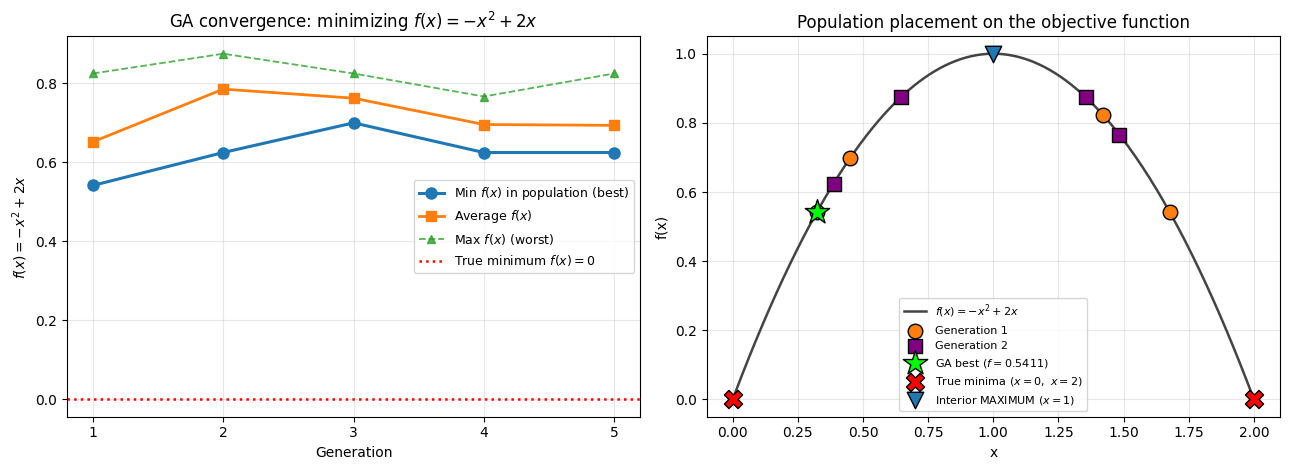

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(log['Generation'], log['Min f(x)'], 'o-', lw=2.2, ms=8,
           color='#1f77b4', label='Min $f(x)$ in population (best)')
ax[0].plot(log['Generation'], log['Avg f(x)'], 's-', lw=2.0, ms=7,
           color='#ff7f0e', label='Average $f(x)$')
ax[0].plot(log['Generation'], log['Max f(x)'], '^--', lw=1.3, ms=6,
           color='#2ca02c', alpha=0.8, label='Max $f(x)$ (worst)')
ax[0].axhline(0, ls=':', c='red', lw=1.8, label='True minimum $f(x)=0$')
ax[0].set_xticks(log['Generation'])
ax[0].set_xlabel('Generation'); ax[0].set_ylabel('$f(x) = -x^2+2x$')
ax[0].set_title('GA convergence: minimizing $f(x)=-x^2+2x$')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

grid = np.linspace(0, 2, 300)
ax[1].plot(grid, f(grid), color='#444', lw=1.8, label='$f(x)=-x^2+2x$')
ax[1].scatter(x_values, f_values, color='#ff7f0e', s=110, ec='k',
              zorder=5, label='Generation 1')
ax[1].scatter(x_values_2, f_values_2, color='purple', marker='s', s=110,
              ec='k', zorder=5, label='Generation 2')
ax[1].scatter([best_x], [best_f], marker='*', s=340, c='lime', ec='k',
              zorder=6, label=f'GA best ($f={best_f:.4f}$)')
ax[1].scatter([0, 2], [0, 0], marker='X', s=170, c='red', ec='k',
              zorder=6, label='True minima ($x=0,\\ x=2$)')
ax[1].scatter([1], [1], marker='v', s=140, c='#1f77b4', ec='k', zorder=6,
              label='Interior MAXIMUM ($x=1$)')
ax[1].set_xlabel('x'); ax[1].set_ylabel('f(x)')
ax[1].set_title('Population placement on the objective function')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 3.11 Parameter Modification

Each parameter is modified **one at a time** from the original configuration, so
that any change in the result is attributable to that parameter alone. The
random seed is held fixed for the same reason.

Because a population-size change cannot start from the given four chromosomes,
that row starts from a seeded random population of the requested size; every
other row keeps the original initial population and the supplied random numbers
for the first generation.

| S. No. | Parameter | Original Value | Modified Value | Effect studied |
|---|---|---|---|---|
| 1 | Crossover site | 1 | 3 | Effect on recombination |
| 2 | Mutation probability $p_m$ | 0.0 | 0.05 | Effect on exploration |
| 3 | Population size $N$ | 4 | 8 | Effect on diversity |
| 4 | Number of generations | 5 | 20 | Effect on convergence |

In [15]:
mods = [
    ('1', 'Crossover site',          'site',        1,   3,    'Effect on recombination'),
    ('2', 'Mutation probability pm', 'pm',        0.0,   0.05, 'Effect on exploration'),
    ('3', 'Population size N',       'pop_size',    4,   8,    'Effect on diversity'),
    ('4', 'Number of generations',   'generations', 5,   20,   'Effect on convergence'),
]

runs = {'Original': log}
rows = []

for sno, label, key, orig_val, new_val, effect in mods:
    p = dict(PARAMS); p[key] = new_val
    if key == 'pop_size':
        p['initial_population'] = None
        p['supplied_randoms'] = None
    mc, mx, mf, mlog = run_ga(**p)
    runs[f'{label} = {new_val}'] = mlog
    rows.append({
        'S. No.': sno, 'Parameter': label,
        'Original Value': orig_val, 'Modified Value': new_val,
        'Original Result': f'x = {best_x:.4f}, f(x) = {best_f:.4f}',
        'Modified Result': f'x = {mx:.4f}, f(x) = {mf:.4f}',
        'Best chromosome': mc,
        'Generations run': f'{len(log)} -> {len(mlog)}',
        'Observation': effect,
    })

mod_table = pd.DataFrame(rows)
mod_table

,S. No.,Parameter,Original Value,Modified Value,Original Result,Modified Result,Best chromosome,Generations run,Observation
0,1,Crossover site,1.0,3.00,"x = 0.3226, f(x) = 0.5411","x = 1.7419, f(x) = 0.4495",11011,5 -> 5,Effect on recombination
1,2,Mutation probability pm,0.0,0.05,"x = 0.3226, f(x) = 0.5411","x = 0.0000, f(x) = 0.0000",00000,5 -> 5,Effect on exploration
2,3,Population size N,4.0,8.00,"x = 0.3226, f(x) = 0.5411","x = 1.9355, f(x) = 0.1249",11110,5 -> 5,Effect on diversity
3,4,Number of generations,5.0,20.00,"x = 0.3226, f(x) = 0.5411","x = 0.3226, f(x) = 0.5411",00101,5 -> 20,Effect on convergence


### 3.12 Comparison of convergence under modified parameters

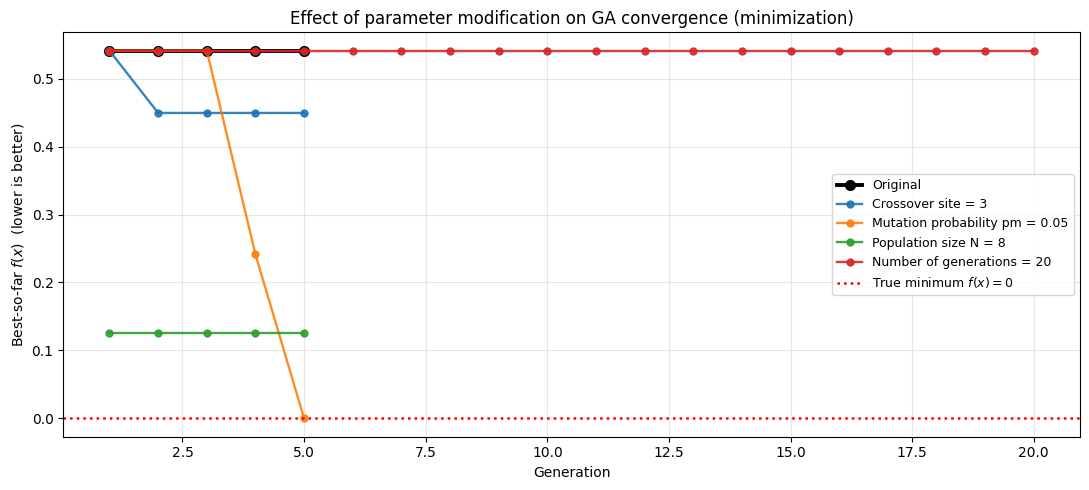

Best-so-far f(x) reached (lower is better), and when it was first hit:
  Original                           : f(x) =  0.5411  first reached at generation 1   (of 5)
  Crossover site = 3                 : f(x) =  0.4495  first reached at generation 2   (of 5)
  Mutation probability pm = 0.05     : f(x) =  0.0000  first reached at generation 5   (of 5)
  Population size N = 8              : f(x) =  0.1249  first reached at generation 1   (of 5)
  Number of generations = 20         : f(x) =  0.5411  first reached at generation 1   (of 20)


In [16]:
plt.figure(figsize=(11, 5))
for name, h in runs.items():
    kw = dict(lw=2.8, color='black', marker='o', ms=7) if name == 'Original' \
         else dict(lw=1.7, alpha=0.9, marker='.', ms=10)
    plt.plot(h['Generation'], h['Best-so-far f(x)'], label=name, **kw)
plt.axhline(0, ls=':', c='red', lw=1.8, label='True minimum $f(x)=0$')
plt.xlabel('Generation'); plt.ylabel('Best-so-far $f(x)$  (lower is better)')
plt.title('Effect of parameter modification on GA convergence (minimization)')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Best-so-far f(x) reached (lower is better), and when it was first hit:")
for name, h in runs.items():
    final = h['Best-so-far f(x)'].iloc[-1]
    first = int(h.loc[h['Best-so-far f(x)'] <= final, 'Generation'].iloc[0])
    print(f"  {name:34s} : f(x) = {final:7.4f}  first reached at generation "
          f"{first}   (of {len(h)})")

### 3.13 Population diversity

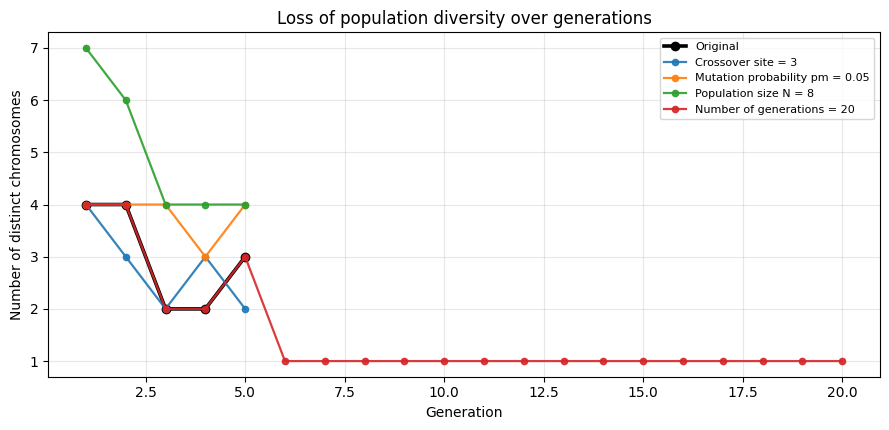

In [17]:
plt.figure(figsize=(9, 4.4))
for name, h in runs.items():
    kw = dict(lw=2.6, color='black', marker='o', ms=6) if name == 'Original' \
         else dict(lw=1.6, alpha=0.9, marker='.', ms=9)
    plt.plot(h['Generation'], h['Distinct chromosomes'], label=name, **kw)
plt.xlabel('Generation'); plt.ylabel('Number of distinct chromosomes')
plt.title('Loss of population diversity over generations')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.14 Observations and Interpretation

**Step 1–2: the decoding formula and the fitness transform.**
The four chromosomes decode to $x \approx 1.6774,\ 0.4516,\ 1.4194,\ 0.3226$
with $f(x) \approx 0.5411,\ 0.6993,\ 0.8241,\ 0.5411$. The check on `10110`
reproduces the value given in the problem ($x = 44/31 = 1.419$), confirming the
encoding is implemented correctly. Note that strings 1 and 4 have *identical*
$f(x) = 0.5411$ despite being far apart in $x$ ($1.6774$ vs $0.3226$) — the
parabola is symmetric about $x = 1$, so points equidistant from the peak are
equally good. Binary encoding is blind to this symmetry: `11010` and `00101`
share no structure at all, yet are equally fit.

**Step 3: selection pressure is almost absent, and this matters.**
The transformed fitnesses are $0.6489,\ 0.5885,\ 0.5482,\ 0.6489$ — a spread of
less than 20% — giving selection probabilities of $0.2665,\ 0.2417,\ 0.2252,
\ 0.2665$ against the $0.25$ that a completely blind lottery would give. The
roulette wheel is therefore nearly uniform, and with the supplied random numbers
each chromosome received **exactly one copy** in the mating pool. Selection did
essentially nothing.

This is a real weakness of the $1/(1+f)$ transform, not an artifact of these
particular numbers. Because $f(x) = x(2-x)$ only ranges over $[0, 1]$ on the
domain, the denominator $1 + f(x)$ only ranges over $[1, 2]$, so transformed
fitness can never differ by more than a factor of two no matter how different
the underlying objective values are. Contrast Experiment 02, where raw $f = x^2$
gave string 3 an actual count of 0 and string 2 a count of 2 in the first
generation. Remedies used in practice include fitness scaling, ranking
selection, or tournament selection — all of which decouple selection pressure
from the raw scale of the objective.

**Step 5–7: crossover at site 1 and the result.**
With site 1, only the leading bit is preserved and bits 2–5 are swapped
wholesale. Generation 2 became `01010`, `10111`, `10101`, `00110` with
$f(x) \approx 0.8741,\ 0.7659,\ 0.8741,\ 0.6243$.

**Generation 2 was worse than Generation 1** on both measures: the best $f(x)$
rose from $0.5411$ to $0.6243$, and the average from $0.6514$ to $0.7846$.
Since this is minimization, higher is worse. Two causes combine. First, with no
selection pressure (above), the mating pool carried no bias towards good
solutions for crossover to exploit. Second, there is **no elitism**: the best
chromosome `11010` was destroyed by crossover and nothing preserved it, so the
population's best genuinely regressed. The best-so-far value of $0.5411$
survives only because the code tracks it separately from the population — which
is exactly why that separate tracking is not optional.

**Iterated run — the GA stalls well short of the optimum.**

| Generation | Best chromosome | Best $x$ | Min $f(x)$ | Distinct |
|---|---|---|---|---|
| 1 | `00101` | 0.3226 | **0.5411** | 4 |
| 2 | `00110` | 0.3871 | 0.6243 | 4 |
| 3 | `00111` | 0.4516 | 0.6993 | 2 |
| 4 | `00110` | 0.3871 | 0.6243 | 2 |
| 5 | `00110` | 0.3871 | 0.6243 | 3 |

The best-so-far value **never improved past generation 1**: $f = 0.5411$ against
a true minimum of $0$, a gap of $0.5411$. The population drifted into the
`001**` neighbourhood ($x \approx 0.32$–$0.45$) and lost diversity, dropping to
two distinct chromosomes by generation 3.

The structural reason is the one flagged in Section 1: the minima of this
function sit at the **boundaries** $x = 0$ and $x = 2$, requiring the chromosomes
`00000` or `11111` — the two most extreme bit patterns in the encoding. Reaching
either demands driving *every* bit to the same value. Crossover cannot manufacture
a bit value that has vanished from the population, and with $p_m = 0$ nothing
else can either. A boundary optimum is therefore the hardest case for a
mutation-free binary GA, and this run demonstrates that directly.

**1. Crossover site: 1 → 3 (recombination).**
Modest improvement: $f = 0.4495$ at $x = 1.7419$ (`11011`). Site 1 preserves
only the leading bit and swaps four; site 3 preserves the leading three and
swaps two. The shorter swap is less **disruptive** — it keeps more of each
parent's high-order structure intact, and since the leading bits dominate the
decoded value of $x$, preserving them preserves most of what made a parent good.
In schema-theory terms, a crossover site near the middle or end has lower
disruption probability for short, high-order building blocks. The result is
better but still far from $0$, confirming that the crossover site was never the
binding constraint.

**2. Mutation probability $p_m$: 0.0 → 0.05 (exploration).**
This is the decisive modification: the GA found the **exact true minimum**,
$f(x) = 0$ at $x = 0$, chromosome `00000`. It is the only configuration tested
that did so, and it reached it at generation 5, having improved steadily rather
than stalling.

The reason follows directly from the diagnosis above. The population had drifted
to `001**`, meaning the two leading bits were already `00` across the
population; mutation only needed to clear the three trailing bits to produce
`00000`, and at $p_m = 0.05$ per bit over five generations that is a likely
event. With $p_m = 0$ it is an impossible one. Mutation is what converts a
boundary optimum from unreachable to reachable, and this pair of runs isolates
that effect as cleanly as any textbook example. The trade-off in the other
direction still holds: too large a $p_m$ degrades the GA towards a random walk.
The usual guide of roughly $1/L = 0.2$ per bit is an upper bound, so $0.05$ is
conservative and still sufficient here.

**3. Population size $N$: 4 → 8 (diversity).**
Substantial improvement: $f = 0.1249$ at $x = 1.9355$ (`11110`), close to the
boundary minimum at $x = 2$. Note which boundary it approached — the *opposite*
one to the mutation run, which converged on $x = 0$. Both are correct, since
$f(0) = f(2) = 0$. A population of 4 is a teaching size: it simply cannot hold
enough distinct bit patterns for recombination to have material to work with,
and a single unlucky roulette spin can eliminate a bit value permanently.
Doubling it gave the GA enough variety to push a chromosome to within one bit of
`11111` without mutation at all. The cost is proportionally more fitness
evaluations per generation, so the fair comparison is per *evaluation*, not per
generation.

**4. Number of generations: 5 → 20 (convergence).**
Quadrupling the generation count changed **nothing**: $f = 0.5411$, first
reached at generation 1 in both runs. Nineteen of the twenty generations did no
useful work. This only makes sense alongside observation 2 — once diversity has
collapsed and $p_m = 0$, there is no mechanism by which the population can
change, so additional generations cannot help. Generation count buys time, not
exploration; it is worth increasing only while diversity survives.

**Overall.** The implementation reproduces the specified decoding formula,
fitness transform, roulette-wheel selection with the supplied random numbers,
and crossover at bit 1 exactly. The analytical verification is the substantive
finding: $f'(x) = 0$ gives $x = 1$, but $f''(x) = -2 < 0$ makes that the
*maximum*, so the true minima are the boundary points $x = 0$ and $x = 2$ with
$f(x) = 0$ — a trap for anyone who solves $f'(x) = 0$ and stops there.

As configured, the GA stalled at $f = 0.5411$ and never improved past its first
generation, for two identifiable reasons: the $1/(1+f)$ transform compressed
selection pressure to near nothing, and with $p_m = 0$ the boundary optima were
unreachable in principle. The parameter study separates the causes cleanly —
mutation probability and population size both produced large improvements
(mutation reaching the exact optimum), while crossover site produced a small one
and extra generations produced none. The general lesson is that on a problem
whose optimum lies at the edge of the encoding, mutation is not a refinement to
the genetic algorithm but a requirement for it to work at all.